In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [4]:
filename = 'US_Baby_Names_1880_2024.csv'

df = pd.read_csv(filename)

df.head()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Sex values:", df["sex"].unique())
print("Year range:", df["year"].min(), "→", df["year"].max())
print("Null counts:\n", df.isnull().sum())
print("\nSample rows:")
print(df.head(10))


Shape: (2149477, 4)
Columns: ['year', 'name', 'sex', 'count']
Sex values: ['F' 'M']
Year range: 1880 → 2024
Null counts:
 year     0
name     0
sex      0
count    0
dtype: int64

Sample rows:
   year       name sex  count
0  1880       Mary   F   7065
1  1880       Anna   F   2604
2  1880       Emma   F   2003
3  1880  Elizabeth   F   1939
4  1880     Minnie   F   1746
5  1880   Margaret   F   1578
6  1880        Ida   F   1472
7  1880      Alice   F   1414
8  1880     Bertha   F   1320
9  1880      Sarah   F   1288


In [15]:
# Total births per year (sum of all name counts)
total_per_year = df.groupby("year")["count"].sum().reset_index(name="total_births")

# Unique names per year (split by sex too)
unique_names = (
    df.groupby(["year", "sex"])["name"]
    .nunique()
    .reset_index(name="unique_names")
)

In [16]:
# Top-10 concentration: % of births going to the 10 most popular names each year
def top10_share(group):
    top10 = group.nlargest(10, "count")["count"].sum()
    total = group["count"].sum()
    return top10 / total * 100

concentration = (
    df.groupby(["year", "sex"])
    .apply(top10_share)
    .reset_index(name="top10_pct")
)

/tmp/ipykernel_24879/3687941512.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top10_share)


In [17]:
# #1 name each year per sex
top1 = (
    df.sort_values("count", ascending=False)
    .groupby(["year", "sex"])
    .first()
    .reset_index()[["year", "sex", "name", "count"]]
)

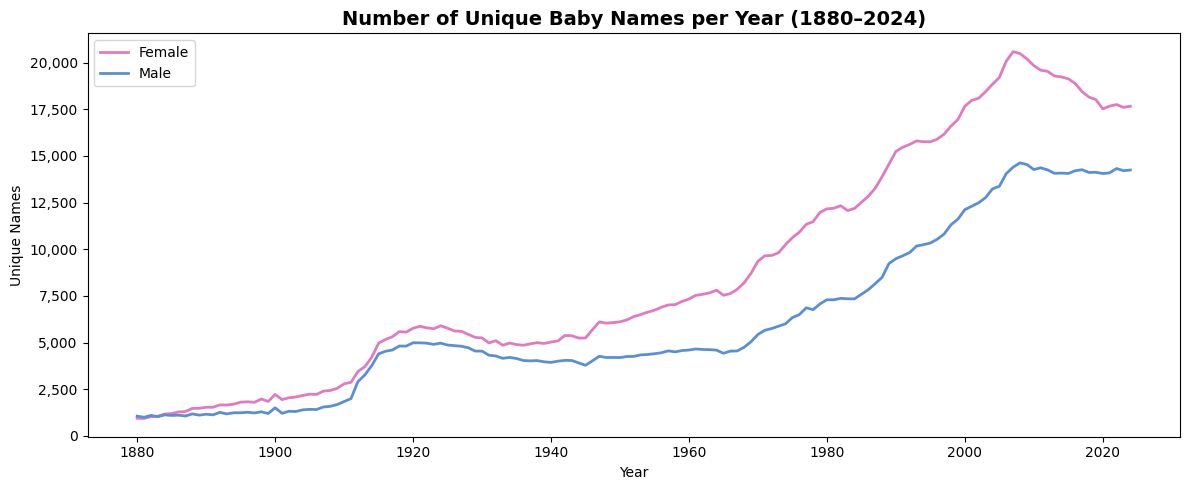

Saved fig1_unique_names.png


In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
for sex, color, label in [("F", "#e07bbf", "Female"), ("M", "#5b8fd4", "Male")]:
    sub = unique_names[unique_names["sex"] == sex]
    ax.plot(sub["year"], sub["unique_names"], color=color, linewidth=2, label=label)

ax.set_title("Number of Unique Baby Names per Year (1880–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Unique Names")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.savefig("fig1_unique_names.png")
plt.show()
print("Saved fig1_unique_names.png")

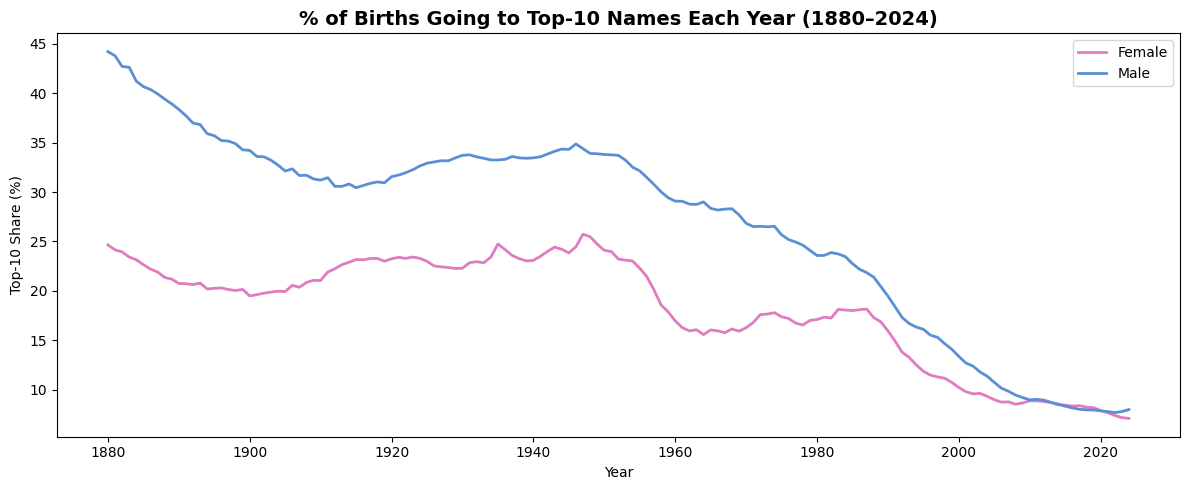

Saved fig2_concentration.png


In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
for sex, color, label in [("F", "#e07bbf", "Female"), ("M", "#5b8fd4", "Male")]:
    sub = concentration[concentration["sex"] == sex]
    ax.plot(sub["year"], sub["top10_pct"], color=color, linewidth=2, label=label)

ax.set_title("% of Births Going to Top-10 Names Each Year (1880–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Top-10 Share (%)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_concentration.png")
plt.show()
print("Saved fig2_concentration.png")

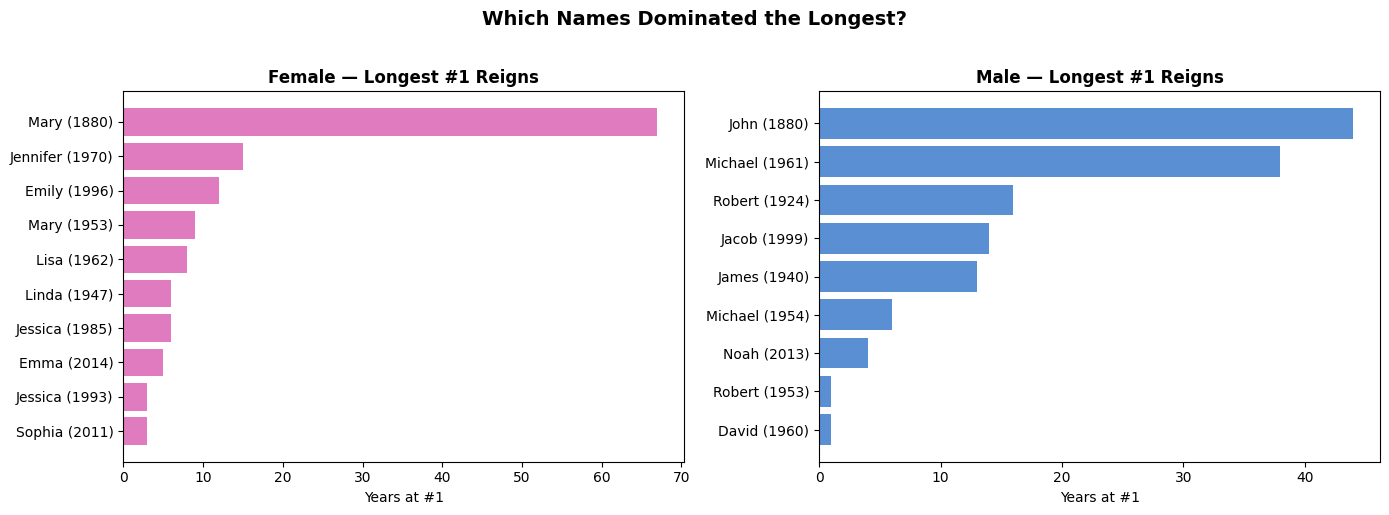

Saved fig3_reign_lengths.png


In [14]:
# How many consecutive years did each name hold the #1 spot?
def reign_lengths(sex_label):
    sub = top1[top1["sex"] == sex_label].sort_values("year")
    reigns = []
    current_name, start = None, None
    for _, row in sub.iterrows():
        if row["name"] != current_name:
            if current_name:
                reigns.append({"name": current_name, "years": row["year"] - start, "start": start})
            current_name, start = row["name"], row["year"]
    return pd.DataFrame(reigns).sort_values("years", ascending=False).head(10)

reign_f = reign_lengths("F")
reign_m = reign_lengths("M")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, reign, color, title in [
    (axes[0], reign_f, "#e07bbf", "Female — Longest #1 Reigns"),
    (axes[1], reign_m, "#5b8fd4", "Male — Longest #1 Reigns"),
]:
    ax.barh(reign["name"] + " (" + reign["start"].astype(str) + ")", reign["years"], color=color)
    ax.invert_yaxis()
    ax.set_xlabel("Years at #1")
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.suptitle("Which Names Dominated the Longest?", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig3_reign_lengths.png")
plt.show()
print("Saved fig3_reign_lengths.png")